# Indonesia Rice Price Forecasting

Proyeksi harga beras bulanan per provinsi menggunakan Spatio-Temporal Graph
Neural Network, dengan data produksi padi dan iklim diuji sumbangannya lewat
ablasi.

Target: harga beras kualitas medium bulanan per provinsi, horizon 1 sampai 3
bulan. Data produksi, cuaca, dan ONI tidak menjadi target, melainkan kandidat
variabel penjelas yang diuji apakah benar-benar memperbaiki akurasi.

Cakupan 34 provinsi yang tercakup PIHPS Bank Indonesia. Empat provinsi hasil
pemekaran Papua tidak tersedia datanya.

# Library

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
from statsmodels.tsa.stattools import adfuller

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 4)

# Data Understanding

Dataset: `data/processed/dataset_gabungan.csv`

Gabungan empat sumber pada resolusi provinsi-bulan:

| Sumber | Isi | Cakupan |
|---|---|---|
| PIHPS Bank Indonesia | harga beras 6 kelas mutu | 2017-03 s.d. 2026-09 |
| BPS (KSA) | luas panen, produksi, fase tanam | 2018-01 s.d. 2026-10 |
| NASA POWER (MERRA-2) | curah hujan, suhu | 2016-01 s.d. 2026-09 |
| NOAA CPC / NOAA PSL | indeks ONI dan DMI | 2016-01 s.d. 2026-08 |

Cakupan: 2016-01 s.d. 2026-10, bulanan, 38 provinsi. 4.940 baris, 35 kolom.

Rentang sengaja dimulai 2016, lebih awal daripada data harga maupun produksi,
supaya tersedia bahan lag untuk baris paling awal.

Keempat sumber punya keterlambatan terbit yang berbeda, dan ini menentukan
variabel mana yang benar-benar tersedia pada saat prediksi dibuat:

| Data | Terbaru | Ketinggalan |
|---|---|---|
| Harga PIHPS | September 2026 | ~0 bulan |
| Curah hujan dan suhu | September 2026 | ~0 bulan |
| ONI | Agustus 2026 | ~1 bulan |
| Produksi BPS (realisasi) | April 2026 | ~5 bulan |
| Fase tanam BPS | Desember 2025 | ~9 bulan |

Perbedaan ini bukan catatan administratif. Harga terbit hampir seketika,
sedangkan produksi terlambat lima bulan dan fase tanam sembilan bulan. Aturan
yang dipakai sepanjang penelitian ini: seluruh variabel penjelas diambil dari
informasi yang tersedia pada saat prediksi dibuat (forecast origin), bukan dari
bulan yang sedang diramalkan (Kadir dkk., 2026).

In [3]:
gab = pd.read_csv(ROOT / "data/processed/dataset_gabungan.csv", parse_dates=["tanggal"])
gab.head(3)

,tanggal,tahun,bulan,provinsi,wilayah_34,sumber,status_luas_panen,status_produksi,luas_panen_ha,produksi_padi_ton_gkg,produksi_beras_ton,standing_crop_ha,vegetatif_awal_ha,vegetatif_akhir_ha,generatif_ha,...,suhu_rata_c,suhu_maks_c,suhu_min_c,n_kab_kota,hari_data,harga_bawah_1,harga_bawah_2,harga_medium_1,harga_medium_2,harga_super_1,harga_super_2,oni,dmi,fase_enso,fase_iod
0,2016-01-01,2016,1,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.72,27.56,22.57,23.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,2.59,0.265,El Nino,Netral
1,2016-02-01,2016,2,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.50,27.44,22.19,23.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,2.50,-0.110,El Nino,Netral
2,2016-03-01,2016,3,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25.37,28.38,23.17,23.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,2.21,-0.008,El Nino,Netral


In [4]:
gab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4940 entries, 0 to 4939
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   tanggal                 4940 non-null   datetime64[ns]
 1   tahun                   4940 non-null   int64         
 2   bulan                   4940 non-null   int64         
 3   provinsi                4940 non-null   object        
 4   wilayah_34              3788 non-null   object        
 5   sumber                  3788 non-null   object        
 6   status_luas_panen       3788 non-null   object        
 7   status_produksi         3788 non-null   object        
 8   luas_panen_ha           3788 non-null   float64       
 9   produksi_padi_ton_gkg   3788 non-null   float64       
 10  produksi_beras_ton      3788 non-null   float64       
 11  standing_crop_ha        3408 non-null   float64       
 12  vegetatif_awal_ha       3408 non-null   float64 

## Data Description
Dataset ini memuat satu target dan tiga kelompok kandidat variabel penjelas.
Targetnya `harga_medium_1`. Kolom produksi, fase tanam, cuaca, dan iklim global
seluruhnya berstatus kandidat yang sumbangannya diuji lewat ablasi, bukan
variabel yang diasumsikan berpengaruh.

### Kolom identitas

| Kolom | Penjelasan |
|---|---|
| `tanggal` | Awal bulan periode data, format `YYYY-MM-01`. Nilainya mewakili **satu bulan penuh**, bukan satu hari |
| `tahun` | Tahun (2016–2026) |
| `bulan` | Bulan, 1 = Januari sampai 12 = Desember |
| `provinsi` | Nama provinsi. 34 provinsi pada 2018–2022, 38 provinsi mulai 2023 setelah pemekaran Papua |
| `wilayah_34` | Provinsi induk sebelum pemekaran. Papua Selatan, Papua Tengah, dan Papua Pegunungan dipetakan ke **Papua**; Papua Barat Daya ke **Papua Barat**. Dipakai kalau ingin membandingkan wilayah secara konsisten sepanjang 2018–2026 |

### Kolom asal dan kualitas data

| Kolom | Penjelasan |
|---|---|
| `sumber` | Asal data. `publikasi` = PDF publikasi tahunan BPS (2018–2025). `webapi` = WebAPI BPS (2026) |
| `status_luas_panen` | Kualitas angka luas panen. `tetap` = angka final. `sementara` = hasil survei, masih bisa direvisi. `potensi` = **perkiraan BPS** dari tanaman yang sedang tumbuh, belum dipanen |
| `status_produksi` | Sama seperti di atas, untuk produksi. Pada 2026: Januari–April `sementara`, Mei–Oktober `potensi` |

Baris berstatus `potensi` adalah **forecast versi BPS**, bukan hasil pengukuran; dipakai sebagai pembanding.

### Kolom hasil panen

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `luas_panen_ha` | hektare | Luas sawah yang dipanen pada bulan tersebut |
| `produksi_padi_ton_gkg` | ton GKG | Produksi padi dalam bentuk **Gabah Kering Giling**. Dihitung BPS sebagai luas panen × produktivitas (hasil survei ubinan). Dipakai sebagai **kandidat variabel penjelas** pada lengan kedua ablasi, bukan sebagai target |
| `produksi_beras_ton` | ton beras | Produksi beras siap konsumsi. Setara 57,6% dari GKG, yaitu rendemen giling 64,02% dikurangi susut, benih, pakan ternak, dan penggunaan non-pangan. Untuk 2026 kolom ini **kami hitung sendiri** dengan faktor 0,5762 karena tidak tersedia di API |

### Kolom fase tanam (hasil pengamatan KSA)

Setiap bulan BPS mengamati ribuan titik sampel dan mencatat kondisi lahannya. Kolom berikut adalah luas lahan pada tiap kondisi. **Hanya tersedia 2018–2025** (dari publikasi PDF); untuk 2026 masih kosong (`NaN`) sampai publikasi edisi 2026 terbit.

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `vegetatif_awal_ha` | hektare | Padi baru ditanam sampai anakan awal. Umumnya dipanen sekitar **3 bulan** kemudian |
| `vegetatif_akhir_ha` | hektare | Padi menjelang berbunga. Umumnya dipanen sekitar **2 bulan** kemudian |
| `generatif_ha` | hektare | Padi sudah berbunga sampai bulir menua. Umumnya dipanen **1 bulan** kemudian |
| `standing_crop_ha` | hektare | Total tanaman padi yang sedang berdiri. **Merupakan penjumlahan tiga kolom di atas** (terverifikasi, selisih ≤ 0,5 ha). Jangan dipakai bersamaan dengan ketiganya sebagai fitur model karena kolinearitas sempurna |
| `persiapan_lahan_ha` | hektare | Lahan sedang diolah atau digenangi, siap ditanami |
| `lahan_bera_ha` | hektare | Lahan sawah dibiarkan kosong (diberakan). Catatan: Januari 2018 bernilai 0 di semua provinsi, kemungkinan **belum didata**, bukan benar-benar nol |
| `tanaman_selain_padi_ha` | hektare | Lahan sawah yang ditanami komoditas lain, misalnya jagung atau sayuran |
| `potensi_gagal_panen_ha` | hektare | Luas tanaman yang berpotensi gagal panen (puso) akibat banjir, kekeringan, atau serangan hama. Di publikasi 2019–2020 istilahnya "Luas Puso"; angkanya identik, jadi digabung jadi satu kolom |

### Kolom cuaca (NASA POWER)

Nilai provinsi dihitung sebagai **rata-rata sederhana seluruh titik kabupaten/kota**
di provinsi tersebut (514 titik, 343 sel grid unik). Rata-rata sederhana dipilih
setelah diuji setara dengan rata-rata berbobot produksi (korelasi 0,995–0,998),
sedangkan satu titik sentra saja hanya 0,94–0,97.

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `curah_hujan_mm` | mm | Total curah hujan sebulan, **dijumlahkan** dari nilai harian lalu dirata-ratakan antar kabupaten |
| `suhu_rata_c` | °C | Suhu rata-rata harian, dirata-ratakan sebulan |
| `suhu_maks_c` | °C | Suhu maksimum harian, dirata-ratakan sebulan |
| `suhu_min_c` | °C | Suhu minimum harian, dirata-ratakan sebulan |
| `n_kab_kota` | jumlah | Banyaknya kabupaten/kota yang dirata-ratakan. Berkisar 4 sampai 38 |
| `hari_data` | jumlah | Banyaknya hari yang tersedia pada bulan itu. **Penanda mutu, wajib dicek** |

**Perhatian pada `hari_data`.** September 2026 hanya punya 13 hari di semua provinsi
karena data ditarik saat bulan berjalan. Akibatnya `curah_hujan_mm` bulan itu adalah
jumlah 13 hari, bukan sebulan penuh, sehingga terlihat seperti kemarau ekstrem padahal
bukan. Baris dengan `hari_data < 28` harus dikeluarkan atau diskalakan sebelum dipakai.
Suhu tidak terkena masalah ini karena dirata-ratakan, bukan dijumlahkan.

### Kolom iklim global

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `oni` | °C | Oceanic Niño Index, simpangan suhu muka laut Pasifik tengah. Positif = El Niño, negatif = La Niña. Nilai musim tiga bulanan dipetakan ke **bulan terakhir** musimnya, bukan bulan tengah, supaya tidak memakai informasi yang belum tersedia saat prediksi dibuat |
| `fase_enso` | kategori | `El Nino` bila ONI ≥ +0,5, `La Nina` bila ≤ −0,5, selain itu `Netral` |
| `dmi` | °C | Dipole Mode Index, ukuran dipol suhu Samudra Hindia. **Disimpan tapi tidak dipakai sebagai fitur** karena korelasinya dengan ONI mencapai 0,79 pada Agustus–November |
| `fase_iod` | kategori | `IOD Positif`, `IOD Negatif`, atau `Netral`. Sama seperti `dmi`, tidak dipakai sebagai fitur |

Kedua kolom iklim global bersifat **nasional**, jadi nilainya sama untuk semua
provinsi pada bulan yang sama.

### Kolom harga (PIHPS Bank Indonesia)

Harga rata-rata bulanan pasar tradisional per provinsi, dalam rupiah per
kilogram. Diambil dari Pusat Informasi Harga Pangan Strategis Bank Indonesia,
portal informasi harga pangan yang terbuka untuk umum.

| Kolom | Penjelasan | Rata-rata |
|---|---|---|
| `harga_bawah_1` | Beras kualitas bawah I | Rp 11.976 |
| `harga_bawah_2` | Beras kualitas bawah II | — |
| `harga_medium_1` | Beras kualitas medium I. **Target utama model** | Rp 13.168 |
| `harga_medium_2` | Beras kualitas medium II | — |
| `harga_super_1` | Beras kualitas super I | Rp 14.454 |
| `harga_super_2` | Beras kualitas super II | — |

Kualitas medium I dipilih sebagai target karena paling banyak dikonsumsi dan
kelengkapannya paling tinggi bersama super I, yaitu 3.827 dari 3.910 sel atau
97,9 persen.

Kekosongan harga seluruhnya menumpuk pada 2017, bukan tersebar. Mulai Oktober
2017 panelnya seimbang sempurna: 108 bulan x 34 provinsi tanpa satu pun nilai
kosong, sehingga tidak diperlukan imputasi.

PIHPS tidak mencakup empat provinsi hasil pemekaran Papua, yang memang sudah
dikeluarkan dari analisis karena riwayat produksinya terlalu pendek.

### Catatan kelengkapan produksi

| Tahun | Baris produksi terisi | Keterangan |
|---|---|---|
| 2016–2017 | 0 | Hanya data iklim, disiapkan sebagai bahan lag |
| 2018–2022 | 408 dari 456 | 34 provinsi; empat provinsi Papua baru belum terbentuk |
| 2023–2025 | 456 | 38 provinsi lengkap |
| 2026 | 380 | Januari–Oktober, dengan Mei ke atas berstatus `potensi` |

Empat provinsi Papua hasil pemekaran (Papua Selatan, Papua Tengah, Papua Pegunungan,
Papua Barat Daya) hanya punya 46 bulan data sejak Januari 2023. Tiga di antaranya
produksinya sangat kecil — Papua Pegunungan rata-rata 18 ton per bulan, dibanding
Aceh 136.450 ton. Riwayatnya terlalu pendek untuk menghitung rata-rata dan simpangan
baku per bulan kalender, sehingga keempatnya dikeluarkan dari analisis yang
membutuhkan baseline musiman.

Kelengkapan harga berbeda polanya. Kekosongan menumpuk pada 2017 saat cakupan
PIHPS belum penuh, bukan tersebar antartahun, sehingga panel harga menjadi
seimbang sempurna mulai Oktober 2017: 108 bulan untuk 34 provinsi tanpa satu pun
nilai kosong.

# Exploratory Data Analysis

In [5]:
NAMA_BULAN = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
              "Jul", "Ags", "Sep", "Okt", "Nov", "Des"]
WARNA = {"utama": "#185FA5", "hijau": "#1D9E75", "oranye": "#D85A30",
         "ungu": "#7F77DD", "abu": "#B4B2A9"}

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

## Panel harga

In [6]:
# Target penelitian: Beras Kualitas Medium I, kelas yang paling banyak dikonsumsi
# sekaligus paling lengkap datanya bersama Super I (97,9 persen terisi).
TARGET = "harga_medium_1"

pv = gab[gab[TARGET].notna()].pivot(index="tanggal", columns="provinsi", values=TARGET)
print(f"panel awal: {pv.shape[0]} bulan x {pv.shape[1]} provinsi | "
      f"kosong {int(pv.isna().sum().sum())}")

# Kekosongan menumpuk di awal 2017 karena cakupan PIHPS belum penuh, bukan tersebar.
for mulai in ("2017-03", "2017-06", "2017-10", "2018-01"):
    s = pv.loc[mulai:]
    print(f"  mulai {mulai}: {s.size:4} sel | kosong {int(s.isna().sum().sum()):3}")

panel awal: 115 bulan x 34 provinsi | kosong 83
  mulai 2017-03: 3910 sel | kosong  83
  mulai 2017-06: 3808 sel | kosong  20
  mulai 2017-10: 3672 sel | kosong   0
  mulai 2018-01: 3570 sel | kosong   0


In [7]:
AWAL_HARGA = "2017-10-01"

pv = pv.loc[AWAL_HARGA:]
harga = gab[(gab.tanggal >= AWAL_HARGA) & gab[TARGET].notna()].copy()
nasional = pv.mean(axis=1)

assert pv.isna().sum().sum() == 0, "panel harga masih ada yang kosong"
print(f"panel terkunci: {pv.shape[0]} bulan x {pv.shape[1]} provinsi, seimbang tanpa imputasi")

panel terkunci: 108 bulan x 34 provinsi, seimbang tanpa imputasi


### Temuan kelengkapan panel

Panel harga seimbang sempurna mulai Oktober 2017, yaitu 108 bulan untuk 34 provinsi atau 3.672 sel tanpa satu pun nilai kosong, karena seluruh kekosongan menumpuk pada awal 2017 saat cakupan PIHPS belum penuh dan bukan tersebar acak, sehingga cukup diselesaikan dengan memotong awal periode tanpa imputasi apa pun; panel ini 30 persen lebih besar daripada panel produksi yang hanya 2.816 baris dan mencakup 34 provinsi dibanding 32, karena DKI Jakarta dan Kepulauan Riau kembali masuk sebagai pasar harga yang sah meski bukan daerah produksi padi.

## Tren harga

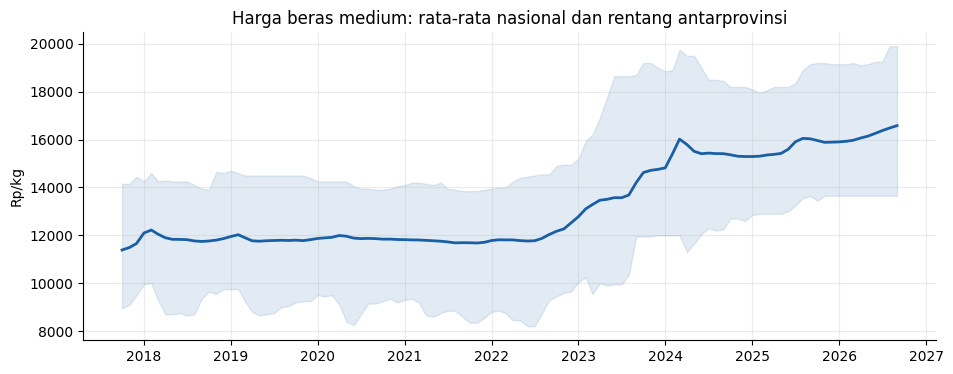

11,388 -> 16,584 Rp/kg (46% dalam 108 bulan)
tren log-linear 4.4% per tahun | bulan naik 58%


In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(nasional.index, nasional.values, lw=2, color=WARNA["utama"])
ax.fill_between(pv.index, pv.min(axis=1), pv.max(axis=1), color=WARNA["utama"], alpha=0.12)
ax.set_ylabel("Rp/kg")
ax.set_title("Harga beras medium: rata-rata nasional dan rentang antarprovinsi")
plt.show()

lp = np.log(nasional)
tren = np.polyfit(np.arange(len(lp)), lp.values, 1)[0] * 12 * 100
print(f"{nasional.iloc[0]:,.0f} -> {nasional.iloc[-1]:,.0f} Rp/kg "
      f"({(nasional.iloc[-1] / nasional.iloc[0] - 1) * 100:.0f}% dalam {len(nasional)} bulan)")
print(f"tren log-linear {tren:.1f}% per tahun | "
      f"bulan naik {(lp.diff().dropna() > 0).mean() * 100:.0f}%")

### Temuan tren

Harga beras medium naik dari Rp 11.388 menjadi Rp 16.584 per kilogram dalam 108 bulan atau 46 persen, setara tren log-linear 4,4 persen per tahun, dan 58 persen bulan mengalami kenaikan sehingga deretnya jelas tidak stasioner; akibatnya model tidak boleh dilatih pada harga mentah karena akan menghabiskan kapasitasnya untuk mempelajari tren dan inflasi alih-alih pergerakan yang benar-benar ingin diramalkan, sehingga target dimodelkan dalam bentuk logaritma mengikuti Kadir dkk. (2026). Pita antarprovinsi juga melebar seiring waktu, menandakan ragam harga ikut tumbuh bersama tingkatnya, yang merupakan alasan kedua memakai logaritma.

## Pola musiman harga

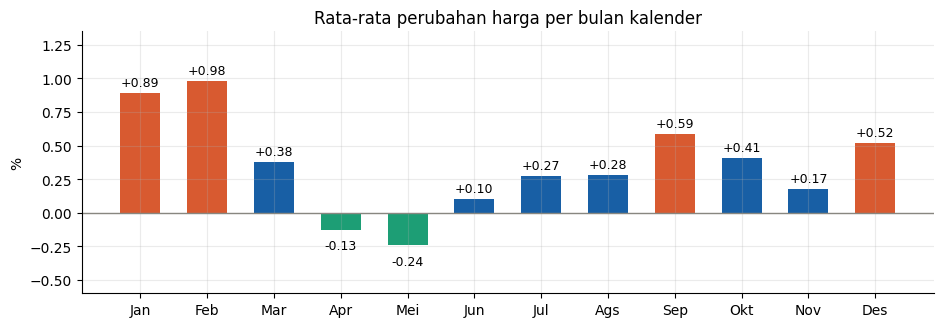

musiman -0.24% (Mei) s.d. +0.98% (Feb)
simpangan baku perubahan bulanan 1.00% | komponen musiman 0.36% -> musim menjelaskan 13% ragam


In [9]:
mom = (lp.diff() * 100).dropna()
musim = mom.groupby(mom.index.month).mean()

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.axhline(0, color="#888780", lw=1)
warna = [WARNA["oranye"] if v > 0.5 else WARNA["hijau"] if v < 0 else WARNA["utama"] for v in musim]
ax.bar(range(1, 13), musim.values, color=warna, width=0.6)
for i, v in musim.items():
    ax.annotate(f"{v:+.2f}", (i, v), xytext=(0, 5 if v > 0 else -14),
                textcoords="offset points", ha="center", fontsize=9)
ax.set_xticks(range(1, 13), NAMA_BULAN)
ax.set_ylim(-0.6, 1.35)
ax.set_ylabel("%")
ax.set_title("Rata-rata perubahan harga per bulan kalender")
plt.show()

print(f"musiman {musim.min():+.2f}% ({NAMA_BULAN[musim.idxmin() - 1]}) s.d. "
      f"{musim.max():+.2f}% ({NAMA_BULAN[musim.idxmax() - 1]})")
print(f"simpangan baku perubahan bulanan {mom.std():.2f}% | komponen musiman {musim.std():.2f}% "
      f"-> musim menjelaskan {(musim.std() / mom.std()) ** 2 * 100:.0f}% ragam")

### Temuan pola musiman

Harga naik paling kencang pada Januari dan Februari, yaitu +0,89 dan +0,98 persen, lalu satu-satunya bulan yang rata-rata turun adalah April dan Mei bertepatan dengan panen raya, sehingga arah musimannya masuk akal secara agronomi; namun besarnya kecil, karena komponen musiman hanya menyumbang 13 persen ragam perubahan bulanan dengan simpangan baku 0,36 persen dibanding 1,00 persen untuk keseluruhan, yang berarti 87 persen pergerakan harga ditentukan hal di luar kalender. Musim tetap dihilangkan sebelum analisis anomali agar perbandingan antarbulan adil, tetapi tidak boleh diandalkan sebagai sumber daya ramal utama sebagaimana pada produksi yang musimannya mencapai 4,4 kali lipat.

## Ko-pergerakan harga antarprovinsi

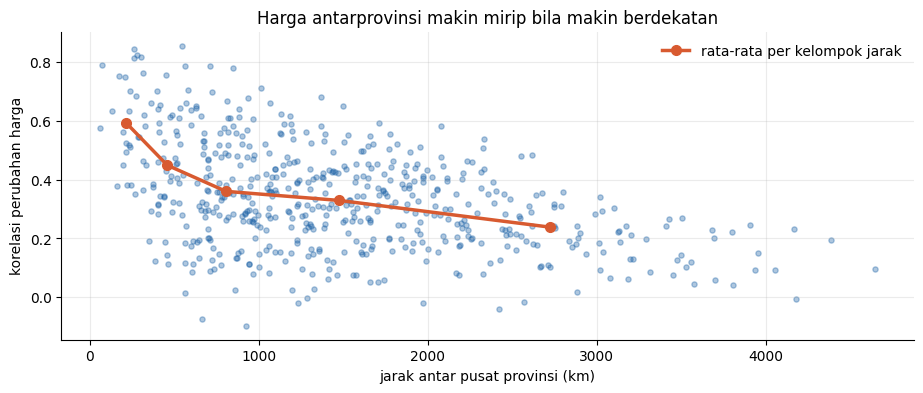

            mean  count
jarak                  
<300       0.594     23
300-600    0.449     61
600-1000   0.360    119
1000-2000  0.329    222
>2000      0.239    136

rata-rata seluruh pasangan 0.338 | korelasi jarak dengan kemiripan -0.443


In [10]:
# Perubahan log bulanan dipakai, bukan harga mentah, supaya tren dan inflasi
# tidak membuat semua provinsi tampak mirip hanya karena sama-sama naik.
dl = np.log(pv).diff().dropna(how="all")
K = dl.corr()

pusat = (pd.read_csv(ROOT / "data/processed/titik_kabupaten.csv")
         .groupby("provinsi")[["lat", "lon"]].mean().reindex(pv.columns))
R_BUMI = 6371
lat, lon = np.radians(pusat.lat.values), np.radians(pusat.lon.values)
hav = (np.sin((lat[:, None] - lat[None, :]) / 2) ** 2
       + np.cos(lat)[:, None] * np.cos(lat)[None, :] * np.sin((lon[:, None] - lon[None, :]) / 2) ** 2)
jarak = 2 * R_BUMI * np.arcsin(np.sqrt(hav))

atas = np.triu_indices(len(pv.columns), 1)
pasangan = pd.DataFrame({"jarak": jarak[atas], "korelasi": K.values[atas]}).dropna()

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(pasangan.jarak, pasangan.korelasi, s=14, alpha=0.35, color=WARNA["utama"])
kelompok = pd.cut(pasangan.jarak, [0, 300, 600, 1000, 2000, 1e5])
rata = pasangan.groupby(kelompok, observed=True).agg(x=("jarak", "mean"), y=("korelasi", "mean"))
ax.plot(rata.x, rata.y, lw=2.5, marker="o", ms=7, color=WARNA["oranye"],
        label="rata-rata per kelompok jarak")
ax.set_xlabel("jarak antar pusat provinsi (km)")
ax.set_ylabel("korelasi perubahan harga")
ax.set_title("Harga antarprovinsi makin mirip bila makin berdekatan")
ax.legend(frameon=False)
plt.show()

print(pasangan.groupby(pd.cut(pasangan.jarak, [0, 300, 600, 1000, 2000, 1e5],
      labels=["<300", "300-600", "600-1000", "1000-2000", ">2000"]),
      observed=True).korelasi.agg(["mean", "count"]).round(3))
print(f"\nrata-rata seluruh pasangan {pasangan.korelasi.mean():.3f} | "
      f"korelasi jarak dengan kemiripan {pasangan.jarak.corr(pasangan.korelasi):+.3f}")

### Temuan ko-pergerakan

Perubahan harga antarprovinsi bergerak bersama dengan kekuatan rata-rata 0,338, dan hubungannya menurun rapi terhadap jarak dari 0,594 untuk pasangan di bawah 300 kilometer menjadi 0,239 untuk pasangan di atas 2.000 kilometer, dengan korelasi jarak terhadap kemiripan sebesar -0,443. Angka ini hampir tiga kali lipat hasil pengujian yang sama pada anomali produksi yang hanya 0,112 secara rata-rata dan 0,287 untuk pasangan terdekat, sehingga memberi dasar empiris yang jauh lebih kuat bagi pendekatan berbasis graf. Temuan ini sejalan dengan literatur integrasi pasar dan transmisi harga beras di Indonesia (Shaffitri dkk., 2024), karena beras memang berpindah antarprovinsi melalui perdagangan sedangkan panen tidak.

## Anomali harga

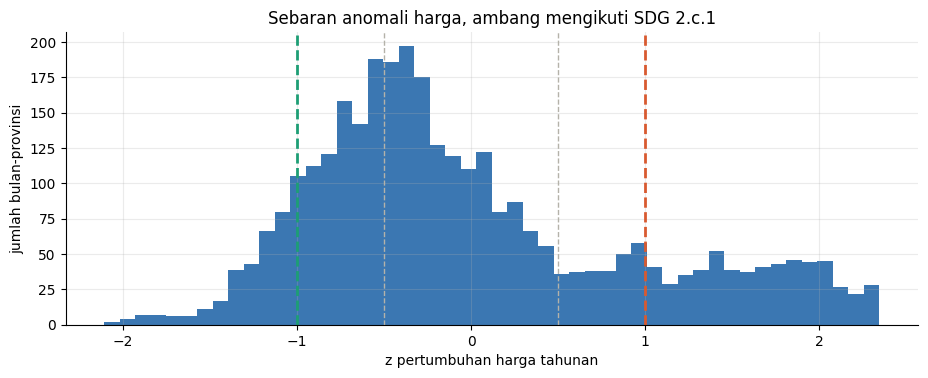

n = 3264
  normal   |z| < 0.5 :  40.8%
  moderat  0.5-1     :  31.3%
  abnormal |z| >= 1  :  27.8%
     di antaranya tinggi 17.7% dan rendah 10.1%


In [11]:
# Mengikuti SDG 2.c.1 Indicator of Food Price Anomalies: pertumbuhan harga dibandingkan terhadap rata-rata historisnya, ambang dinyatakan dalam simpangan baku.
anom = np.log(pv).stack().rename("lp").reset_index()
anom.columns = ["tanggal", "provinsi", "lp"]
anom["bulan"] = anom.tanggal.dt.month
anom = anom.sort_values(["provinsi", "tanggal"])

# Pertumbuhan tahunan dipakai agar musim dan inflasi jangka pendek ikut ternetralkan.
anom["cgr"] = anom.groupby("provinsi").lp.diff(12) * 100
acuan = anom.groupby([anom.provinsi, anom.bulan]).cgr
anom["z"] = (anom.cgr - acuan.transform("mean")) / acuan.transform("std")

z = anom.z.dropna()
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.hist(z, bins=50, color=WARNA["utama"], alpha=0.85)
for x, c in ((-1, WARNA["hijau"]), (-0.5, WARNA["abu"]), (0.5, WARNA["abu"]), (1, WARNA["oranye"])):
    ax.axvline(x, color=c, lw=2 if abs(x) == 1 else 1, ls="--")
ax.set_xlabel("z pertumbuhan harga tahunan")
ax.set_ylabel("jumlah bulan-provinsi")
ax.set_title("Sebaran anomali harga, ambang mengikuti SDG 2.c.1")
plt.show()

print(f"n = {len(z)}")
print(f"  normal   |z| < 0.5 : {(z.abs() < 0.5).mean() * 100:5.1f}%")
print(f"  moderat  0.5-1     : {((z.abs() >= 0.5) & (z.abs() < 1)).mean() * 100:5.1f}%")
print(f"  abnormal |z| >= 1  : {(z.abs() >= 1).mean() * 100:5.1f}%")
print(f"     di antaranya tinggi {(z >= 1).mean() * 100:.1f}% dan rendah {(z <= -1).mean() * 100:.1f}%")

### Temuan anomali

Dengan ambang SDG 2.c.1, sebanyak 40,8 persen bulan-provinsi tergolong normal, 31,3 persen moderat, dan 27,8 persen abnormal, yang berarti anomali harga bukan kejadian langka melainkan rutin sehingga ambang ini layak dipakai tanpa perlu dilonggarkan. Sebarannya menceng ke kanan secara nyata, karena anomali tinggi mencapai 17,7 persen sedangkan anomali rendah hanya 10,1 persen, artinya lonjakan harga lebih sering terjadi daripada penurunan sebesar itu. Ketidaksimetrisan ini penting bagi pemodelan maupun aplikasi, sebab kesalahan meramal ke arah bawah lebih sering terjadi dan lebih merugikan pengguna daripada kesalahan ke arah atas.

## Hubungan dengan produksi dan iklim

In [12]:
# Pratinjau ablasi kedua: apakah data panen dan iklim memang menjelaskan harga.
m = gab[(gab.tanggal >= AWAL_HARGA) & gab[TARGET].notna()].sort_values(["provinsi", "tanggal"]).copy()
m.loc[m.status_produksi == "potensi", "produksi_padi_ton_gkg"] = np.nan

m["y"] = m.groupby("provinsi")[TARGET].transform(lambda s: np.log(s).shift(-3) - np.log(s))
musim_y = m.groupby([m.provinsi, m.bulan]).y
m["y"] = m.y - musim_y.transform("mean")


def anomali(kolom):
    s = m[kolom]
    g = s.groupby([m.provinsi, m.bulan])
    return (s - g.transform("mean")) / g.transform("std")


print("korelasi perubahan harga 3 bulan ke depan dengan fitur, pada lag yang tersedia:\n")
for nama, kolom, lags in (("produksi", "produksi_padi_ton_gkg", (6, 9, 12)),
                          ("curah hujan", "curah_hujan_mm", (1, 6, 12)),
                          ("suhu", "suhu_rata_c", (1, 6, 9)),
                          ("ONI", "oni", (1, 6, 9))):
    m["a"] = m.oni if kolom == "oni" else anomali(kolom)
    hasil = {L: round(m.y.corr(m.groupby("provinsi").a.shift(L)), 3) for L in lags}
    print(f"  {nama:12} {hasil}")

korelasi perubahan harga 3 bulan ke depan dengan fitur, pada lag yang tersedia:

  produksi     {6: np.float64(-0.001), 9: np.float64(-0.014), 12: np.float64(-0.014)}
  curah hujan  {1: np.float64(0.004), 6: np.float64(0.05), 12: np.float64(0.184)}
  suhu         {1: np.float64(0.005), 6: np.float64(-0.08), 9: np.float64(-0.179)}
  ONI          {1: np.float64(0.024), 6: np.float64(-0.248), 9: np.float64(-0.289)}


### Temuan hubungan dengan produksi dan iklim

Produksi padi praktis tidak menjelaskan pergerakan harga, dengan korelasi hanya -0,001 sampai -0,014 pada seluruh lag yang benar-benar tersedia, sehingga dugaan umum bahwa harga beras mengikuti panen tidak didukung data pada resolusi ini; hasil ini sejalan dengan Fadilah (2025) yang menemukan konsumsi dan bukan produksi sebagai penentu harga, serta Yafi (2025) yang menemukan produksi berpengaruh pada impor alih-alih langsung pada harga. Variabel iklim menunjukkan angka lebih besar, yaitu curah hujan 0,184 pada lag 12 dan ONI -0,289 pada lag 9, tetapi keduanya harus dibaca hati-hati karena sepanjang periode ini hanya terdapat empat episode El Nino dan empat La Nina, dan korelasi ONI turun dari -0,289 menjadi -0,112 bila tahun 2023 dan 2024 dikeluarkan. Keempat variabel tetap diikutsertakan sebagai lengan kedua ablasi, dengan catatan bahwa kesimpulan apa pun harus diuji signifikansinya, bukan disimpulkan dari selisih MAPE semata.

# Preprocessing

## Filtering dan Penandaan Mutu

Kriteria penyaringan mengikuti target, yaitu kelengkapan harga, bukan riwayat
panen. Provinsi dipertahankan bila harganya lengkap sepanjang jendela analisis.
Kolom produksi dan iklim tidak menentukan provinsi mana yang masuk, karena
statusnya hanya kandidat variabel penjelas.

In [13]:
TARGET = "harga_medium_1"
AWAL = "2018-01-01"
AKHIR = "2026-04-01"

KOLOM_DIPAKAI = [
    "tanggal", "tahun", "bulan", "provinsi",      # kunci
    "harga_medium_1", "harga_super_1",            # target dan pembanding mutu
    "produksi_padi_ton_gkg", "curah_hujan_mm",    # kandidat variabel penjelas
    "suhu_rata_c", "oni",
]

# 1. Pertahankan provinsi yang harganya lengkap. Empat provinsi pemekaran Papua tidak tercakup PIHPS sama sekali.
pv_cek = gab[gab[TARGET].notna()].pivot(index="tanggal", columns="provinsi", values=TARGET).loc["2017-10":]
lengkap = sorted(pv_cek.columns[pv_cek.isna().sum() == 0])
provinsi_dibuang = sorted(set(gab.provinsi) - set(lengkap))

model = gab[gab.provinsi.isin(lengkap)].sort_values(["provinsi", "tanggal"]).copy()

# 2. Kosongkan curah hujan pada bulan yang datanya belum lengkap.
belum_lengkap = model.hari_data.notna() & (model.hari_data < 28)
model.loc[belum_lengkap, "curah_hujan_mm"] = np.nan

# 3. Angka berstatus potensi adalah ramalan BPS, bukan pengukuran.
model["produksi_padi_ton_gkg"] = model.produksi_padi_ton_gkg.where(model.status_produksi != "potensi")

# 4. Potong ke rentang bersama.
model = model[(model.tanggal >= AWAL) & (model.tanggal <= AKHIR)].reset_index(drop=True)

# 5. Buang kolom yang tidak dipakai. 
kolom_dibuang = [k for k in model.columns if k not in KOLOM_DIPAKAI]
model = model[KOLOM_DIPAKAI]

n_prov, n_bulan = model.provinsi.nunique(), model.tanggal.nunique()
assert len(model) == n_prov * n_bulan, "panel tidak seimbang"
assert model.isna().sum().sum() == 0, "masih ada nilai kosong"

print(f"provinsi dibuang ({len(provinsi_dibuang)}): {', '.join(provinsi_dibuang)}")
print(f"kolom dibuang ({len(kolom_dibuang)}): {', '.join(kolom_dibuang[:6])}, ...")
print(f"curah hujan dikosongkan: {int(belum_lengkap.sum())} baris")
print(f"baris: {len(gab)} -> {len(model)} | {n_prov} provinsi x {n_bulan} bulan")
print(f"rentang: {model.tanggal.min():%Y-%m} s.d. {model.tanggal.max():%Y-%m}")
print(f"panel seimbang: True | nilai kosong: 0")

provinsi dibuang (4): Papua Barat Daya, Papua Pegunungan, Papua Selatan, Papua Tengah
kolom dibuang (25): wilayah_34, sumber, status_luas_panen, status_produksi, luas_panen_ha, produksi_beras_ton, ...
curah hujan dikosongkan: 34 baris
baris: 4940 -> 3400 | 34 provinsi x 100 bulan
rentang: 2018-01 s.d. 2026-04
panel seimbang: True | nilai kosong: 0


## Handling Missing Value

In [14]:
# Cek Missing Value
print("Missing Values:\n", model.isnull().sum())

Missing Values:
 tanggal                  0
tahun                    0
bulan                    0
provinsi                 0
harga_medium_1           0
harga_super_1            0
produksi_padi_ton_gkg    0
curah_hujan_mm           0
suhu_rata_c              0
oni                      0
dtype: int64


### Perlakuan nilai kosong

Target tidak memiliki nilai kosong sama sekali, dan seluruh kolom inti juga sudah penuh setelah rentang analisis disamakan, sehingga tidak ada baris yang perlu dibuang maupun diisi. Kekosongan yang tersisa hanya pada delapan kolom fase tanam sebanyak 136 baris, yaitu 34 provinsi dikali empat bulan Januari sampai April 2026, karena publikasi KSA bersifat tahunan dan edisi 2026 belum terbit.

Kekosongan tersebut tidak diimputasi karena sifatnya struktural. Datanya memang belum pernah diukur, bukan hilang secara acak dan letaknya di ujung deret sehingga pengisian apa pun sama dengan peramalan, bukan interpolasi. Kekosongan juga tidak dibuang pada tahap ini, sebab empat bulan tersebut masih diperlukan sebagai nilai target bagi horizon tiga bulan, sedangkan kolom fase tanam hanya dipakai oleh satu lengan ablasi. Penyaringan baris akhirnya dilakukan pada tahap penyusunan tabel model sesuai kebutuhan masing-masing lengan.

## Handling Duplicate Data

In [15]:
print("Jumlah duplikat identik:", model.duplicated().sum())

model = model.drop_duplicates(keep="first")

print("Jumlah data setelah hapus duplikat identik:", len(model))


Jumlah duplikat identik: 0
Jumlah data setelah hapus duplikat identik: 3400


# Feature Engineering

In [16]:
# Semua penggeseran WAJIB per provinsi. Tanpa groupby, nilai provinsi terakhir bocor jadi lag provinsi berikutnya.
def lag(kolom, k):
    return model.groupby("provinsi")[kolom].shift(k)

def gulir(kolom, jendela, fungsi):
    return model.groupby("provinsi")[kolom].transform(lambda s: getattr(s.rolling(jendela), fungsi)())

CONTOH = (model.provinsi == "Jawa Barat") & (model.tahun == 2024)

model["lharga"] = np.log(model[TARGET])

model.loc[CONTOH, ["tanggal", TARGET, "lharga"]].head(3)

,tanggal,harga_medium_1,lharga
872,2024-01-01,14450.0,9.578450
873,2024-02-01,15700.0,9.661416
874,2024-03-01,16000.0,9.680344


## Momentum Harga

Perubahan log harga pada beberapa horizon. Satu bulan menangkap gerakan terbaru,
tiga bulan menangkap arah jangka menengah, dua belas bulan menangkap posisi
terhadap tahun lalu sekaligus menetralkan musim.

In [17]:
for W in (1, 3, 12):
    model[f"ret{W}"] = model.lharga - lag("lharga", W)

model.loc[CONTOH, ["tanggal", TARGET, "ret1", "ret3", "ret12"]].head(4)

,tanggal,harga_medium_1,ret1,ret3,ret12
872,2024-01-01,14450.0,0.017452,0.020980,0.177489
873,2024-02-01,15700.0,0.082966,0.103946,0.223940
874,2024-03-01,16000.0,0.018928,0.119347,0.238892
875,2024-04-01,15550.0,-0.028528,0.073366,0.210364


## Volatilitas

Simpangan baku perubahan bulanan selama enam bulan terakhir. Jendela tiga bulan
diuji lebih dulu namun berkorelasi 0,755 dengan yang enam bulan, sehingga hanya
satu yang dipertahankan.

In [18]:
model["vol6"] = model.groupby("provinsi").lharga.transform(lambda s: s.diff().rolling(6).std())

model.loc[CONTOH, ["tanggal", "ret1", "vol6"]].head(4)

,tanggal,ret1,vol6
872,2024-01-01,0.017452,0.033311
873,2024-02-01,0.082966,0.040680
874,2024-03-01,0.018928,0.030424
875,2024-04-01,-0.028528,0.037119


## Gerakan Pasar Nasional

Rata-rata perubahan harga seluruh provinsi pada bulan yang sama. Dua fitur ini
adalah prediktor terkuat terhadap perubahan harga tiga bulan ke depan, dengan
korelasi 0,181 dan 0,175 lebih kuat daripada momentum provinsi itu sendiri.

Artinya harga provinsi lebih mengikuti gerakan bersama daripada dinamikanya
sendiri, dan itu persis struktur yang diharapkan ditangkap graf. Kedua fitur ini
juga menjadi pembanding yang adil bagi lengan Transformers, supaya keunggulan
ST-GNN nanti tidak semata berasal dari akses ke informasi antarprovinsi.

In [19]:
model["ret1_nas"] = model.groupby("tanggal").ret1.transform("mean")
model["ret3_nas"] = model.groupby("tanggal").ret3.transform("mean")

model.loc[CONTOH, ["tanggal", "ret1", "ret1_nas", "ret3", "ret3_nas"]].head(4)

,tanggal,ret1,ret1_nas,ret3,ret3_nas
872,2024-01-01,0.017452,0.004763,0.020980,0.013556
873,2024-02-01,0.082966,0.040034,0.103946,0.047459
874,2024-03-01,0.018928,0.037864,0.119347,0.082662
875,2024-04-01,-0.028528,-0.015140,0.073366,0.062759


## Posisi terhadap Rata-rata

Jarak harga sekarang terhadap rata-rata dua belas bulannya, sebagai penanda
kemungkinan koreksi balik. Fitur `ret6` diuji sebagai alternatif namun
berkorelasi 0,936 dengan fitur ini, sehingga hanya satu yang dipakai.

In [20]:
model["jarak_ma12"] = model.lharga - gulir("lharga", 12, "mean")

model.loc[CONTOH, ["tanggal", TARGET, "jarak_ma12"]].head(4)

,tanggal,harga_medium_1,jarak_ma12
872,2024-01-01,14450.0,0.087477
873,2024-02-01,15700.0,0.151782
874,2024-03-01,16000.0,0.150802
875,2024-04-01,15550.0,0.104744


## Selisih Mutu

Selisih relatif harga beras super terhadap medium. Selisih yang melebar
menandakan beras bermutu baik menjadi langka relatif terhadap yang biasa.
Rata-ratanya 9,9 persen dengan simpangan 7,5 persen, jadi variasinya nyata.
Kolom `harga_super_1` dipakai karena satu-satunya kelas mutu lain yang lengkap
di seluruh 34 provinsi.

In [21]:
model["selisih_mutu"] = (model.harga_super_1 - model[TARGET]) / model[TARGET]

model.loc[CONTOH, ["tanggal", TARGET, "harga_super_1", "selisih_mutu"]].head(4)

,tanggal,harga_medium_1,harga_super_1,selisih_mutu
872,2024-01-01,14450.0,15700.0,0.086505
873,2024-02-01,15700.0,16950.0,0.079618
874,2024-03-01,16000.0,17200.0,0.075000
875,2024-04-01,15550.0,16800.0,0.080386


## Kandidat Produksi dan Iklim

Kelompok fitur untuk lengan ablasi kedua. Lag dipilih dari yang tersedia saat
prediksi dibuat sekaligus terkuat pada pengujian EDA: produksi minimal enam
bulan karena BPS terlambat segitu, curah hujan dua belas bulan, suhu sembilan
bulan, dan ONI enam sampai sembilan bulan.

Korelasi mentahnya kecil, produksinya bahkan mendekati nol, sehingga kemungkinan
besar kelompok ini tidak akan menambah akurasi. Itulah yang diuji.

In [ ]:
def anomali(kolom):
    s = np.log1p(model[kolom])
    g = s.groupby([model.provinsi, model.bulan])
    return (s - g.transform("mean")) / g.transform("std")


model["a_prod"] = anomali("produksi_padi_ton_gkg")
model["prod6"] = lag("a_prod", 6)
model["prod_ma6"] = gulir("a_prod", 6, "mean").groupby(model.provinsi).shift(6)
model["hujan12"] = lag("curah_hujan_mm", 12)
model["suhu9"] = lag("suhu_rata_c", 9)
model["oni6"] = lag("oni", 6)
model["oni9"] = lag("oni", 9)

model.loc[CONTOH, ["tanggal", "prod6", "prod_ma6", "hujan12", "suhu9", "oni6"]].head(4)

,tanggal,prod6,prod_ma6,hujan12,suhu9,oni6
872,2024-01-01,13.702824,13.753307,199.34,24.96,0.73
873,2024-02-01,13.379517,13.761697,334.35,25.05,1.00
874,2024-03-01,13.478964,13.648592,295.14,24.66,1.25
875,2024-04-01,13.583444,13.596633,270.96,23.85,1.50


## Encoding

In [23]:
model["bulan_kode"] = model.bulan - 1
PROVINSI = sorted(model.provinsi.unique())
KODE_PROVINSI = {nama: i for i, nama in enumerate(PROVINSI)}
model["provinsi_kode"] = model.provinsi.map(KODE_PROVINSI)

(ROOT / "data/processed/kode_provinsi.json").write_text(
    json.dumps(KODE_PROVINSI, indent=2, ensure_ascii=False), encoding="utf-8")

assert model.groupby("provinsi").provinsi_kode.nunique().eq(1).all()
print(f"{len(PROVINSI)} provinsi -> kode 0..{len(PROVINSI) - 1} | bulan -> 0..11")
print("tersimpan:", ROOT / "data/processed/kode_provinsi.json")

34 provinsi -> kode 0..33 | bulan -> 0..11
tersimpan: e:\Platinum\Important\Collage\Semester 7\PDA\data\processed\kode_provinsi.json


## Target

Target adalah **perubahan** log harga, bukan tingkatnya. Harga sangat lengket:
menebak harga tiga bulan ke depan sama dengan harga sekarang sudah menghasilkan
MAPE 2,31 persen dan korelasi 0,978. Dengan target tingkat, setiap model akan
memperoleh R2 di atas 0,95 tanpa mempelajari apa pun selain menyalin angka
terakhir, dan ablasinya kehilangan daya pembeda.

Dengan target perubahan, pembandingnya tegas yaitu menebak tidak ada perubahan,
dan selisih antar lengan menjadi bermakna. Untuk aplikasi, prediksi tinggal
dijumlahkan kembali ke harga sekarang sehingga pengguna tetap melihat rupiah.

In [24]:
for H in (1, 2, 3):
    model[f"dy{H}"] = model.groupby("provinsi").lharga.shift(-H) - model.lharga

TARGET_MODEL = ["dy1", "dy2", "dy3"]

cek = model.dropna(subset=TARGET_MODEL)
print(f"simpangan baku dy3: {cek.dy3.std() * 100:.2f}% | "
      f"rentang {cek.dy3.min() * 100:+.1f}% s.d. {cek.dy3.max() * 100:+.1f}%")
print(f"pembanding naif (tebak 0): MAE {cek.dy3.abs().mean() * 100:.2f}%")

model.loc[CONTOH, ["tanggal", TARGET, "dy1", "dy2", "dy3"]].head(4)

simpangan baku dy3: 3.53% | rentang -20.3% s.d. +19.2%
pembanding naif (tebak 0): MAE 2.25%


,tanggal,harga_medium_1,dy1,dy2,dy3
872,2024-01-01,14450.0,0.082966,0.101894,0.073366
873,2024-02-01,15700.0,0.018928,-0.009600,-0.045611
874,2024-03-01,16000.0,-0.028528,-0.064539,-0.067877
875,2024-04-01,15550.0,-0.036010,-0.039349,-0.036010


## Daftar Fitur dan Pemeriksaan

In [26]:
KELOMPOK_FITUR = {
    "harga":    ["ret1", "ret3", "ret12", "vol6", "ret1_nas", "ret3_nas", "jarak_ma12", "selisih_mutu"],
    "kalender": ["bulan_kode", "provinsi_kode"],
    "produksi": ["prod6", "prod_ma6"],
    "iklim":    ["hujan12", "suhu9", "oni6", "oni9"],
}
FITUR = [f for kelompok in KELOMPOK_FITUR.values() for f in kelompok]

siap = model.dropna(subset=FITUR + TARGET_MODEL)
seimbang = len(siap) == siap.provinsi.nunique() * siap.tanggal.nunique()
print(f"{len(FITUR)} fitur | {len(siap)} baris | "
      f"{siap.tanggal.min():%Y-%m} s.d. {siap.tanggal.max():%Y-%m} | seimbang {seimbang}")

16 fitur | 2890 baris | 2019-01 s.d. 2026-01 | seimbang True


# Feature Selection

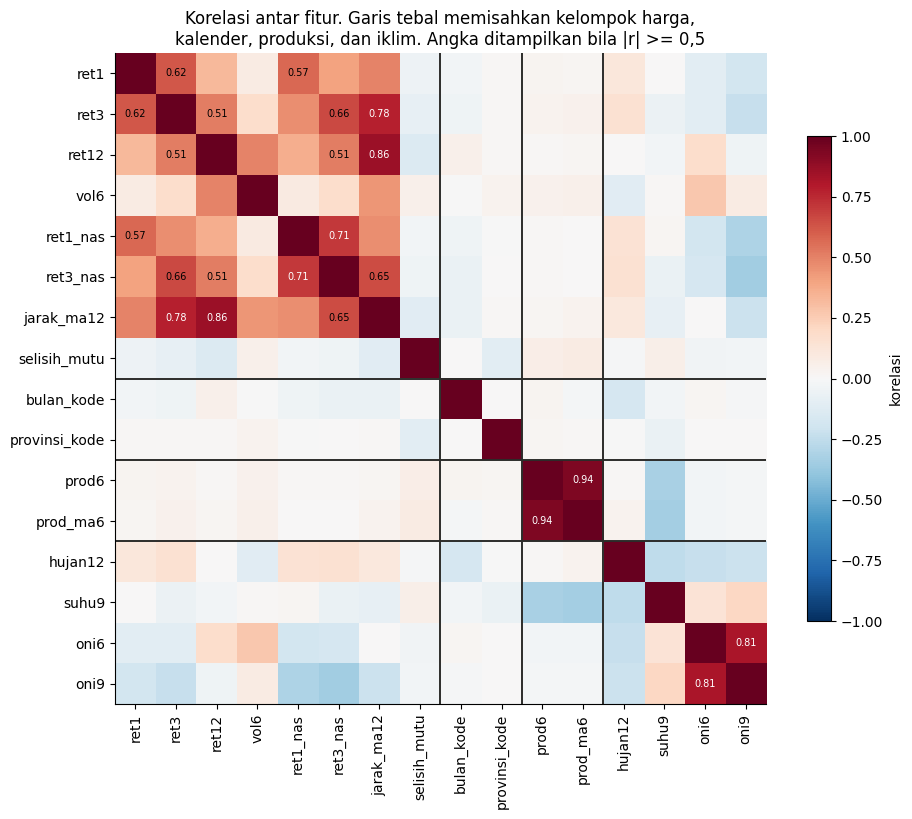

lima pasangan paling mirip:
  prod6          x prod_ma6       0.936
  ret12          x jarak_ma12     0.859
  oni6           x oni9           0.813
  ret3           x jarak_ma12     0.776
  ret1_nas       x ret3_nas       0.708

pasangan di atas ambang 0.9: 1

korelasi mutlak tiap fitur terhadap dy3:
oni9             0.287
oni6             0.247
ret1_nas         0.181
ret3_nas         0.175
ret12            0.153
bulan_kode       0.137
ret1             0.085
jarak_ma12       0.078
selisih_mutu     0.076
hujan12          0.067
suhu9            0.048
vol6             0.031
ret3             0.030
prod6            0.027
prod_ma6         0.016
provinsi_kode    0.004


AssertionError: masih ada pasangan fitur kembar

In [27]:
AMBANG_KEMBAR = 0.9

C = model[FITUR].corr()

fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FITUR)), FITUR, rotation=90)
ax.set_yticks(range(len(FITUR)), FITUR)

# Angka hanya ditampilkan bila cukup besar, supaya petaknya tetap terbaca.
for i in range(len(FITUR)):
    for j in range(len(FITUR)):
        v = C.values[i, j]
        if i != j and abs(v) >= 0.5:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.7 else "black")

# Garis pemisah antar kelompok fitur, mengikuti urutan KELOMPOK_FITUR.
for batas in np.cumsum([len(k) for k in KELOMPOK_FITUR.values()])[:-1]:
    ax.axhline(batas - 0.5, color="#2C2C2A", lw=1.4)
    ax.axvline(batas - 0.5, color="#2C2C2A", lw=1.4)

ax.grid(False)
ax.set_title("Korelasi antar fitur. Garis tebal memisahkan kelompok harga,\n"
             "kalender, produksi, dan iklim. Angka ditampilkan bila |r| >= 0,5")
fig.colorbar(im, ax=ax, shrink=0.7, label="korelasi")
plt.show()

atas = np.triu(np.ones(C.shape, dtype=bool), 1)
tertinggi = C.abs().where(atas).stack().sort_values(ascending=False)
print("lima pasangan paling mirip:")
for (a, b), v in tertinggi.head(5).items():
    print(f"  {a:14} x {b:14} {v:.3f}")
print(f"\npasangan di atas ambang {AMBANG_KEMBAR}: {(tertinggi > AMBANG_KEMBAR).sum()}")

print("\nkorelasi mutlak tiap fitur terhadap dy3:")
print(siap[FITUR].corrwith(siap.dy3).abs().sort_values(ascending=False).round(3).to_string())

assert tertinggi.iloc[0] <= AMBANG_KEMBAR, "masih ada pasangan fitur kembar"

# Split Train & Test